In [62]:
!pip install mplfinance

In [63]:
!pip install yfinance

In [64]:
import pandas as pd
import yfinance as yf
import mplfinance as mpf

In [65]:
data = yf.download('AAPL', start='2020-01-01', end='2023-01-01')

[*********************100%***********************]  1 of 1 completed


In [66]:
if isinstance(data, pd.DataFrame):
    print("Data is a DataFrame")

Data is a DataFrame


In [67]:
if isinstance(data.columns, pd.MultiIndex):
    print("Data is a DataFrame")
    data.columns = data.columns.droplevel(1)

Data is a DataFrame


In [68]:
data.head(10)

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200
2020-01-09,74.568779,74.761442,73.742727,73.993187,170108400
2020-01-10,74.737358,75.300911,74.236431,74.802387,140644800
2020-01-13,76.334099,76.360594,74.934866,75.052878,121532000
2020-01-14,75.303322,76.480993,75.180503,76.271471,161954400


In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2020-01-02 to 2022-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   756 non-null    float64
 1   High    756 non-null    float64
 2   Low     756 non-null    float64
 3   Open    756 non-null    float64
 4   Volume  756 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.4 KB


In [70]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [71]:
data.describe()


Price,Close,High,Low,Open,Volume
count,756.000000,756.000000,756.000000,756.000000,7.560000e+02
mean,127.128756,128.671054,125.473653,127.051113,1.120920e+08
std,30.301250,30.577591,30.020452,30.329239,5.602586e+07
min,54.163712,55.160709,51.324807,55.059320,3.519590e+07
25%,112.264151,113.753667,110.812212,112.443589,7.636470e+07
50%,132.485184,133.613814,130.532820,132.307418,9.493580e+07
75%,147.635796,148.798280,145.698890,147.005587,1.296327e+08
max,177.939728,178.848946,175.114365,178.545881,4.265100e+08


# Exploratory Data Analysis (EDA) on the stock data

## Visualization

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 1400x800 with 0 Axes>

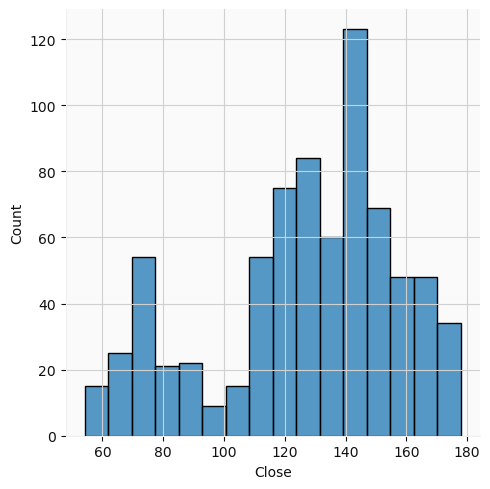

In [73]:
plt.figure(figsize=(14, 8))
sns.displot(data['Close'])
plt.show() 

<Figure size 1400x800 with 0 Axes>

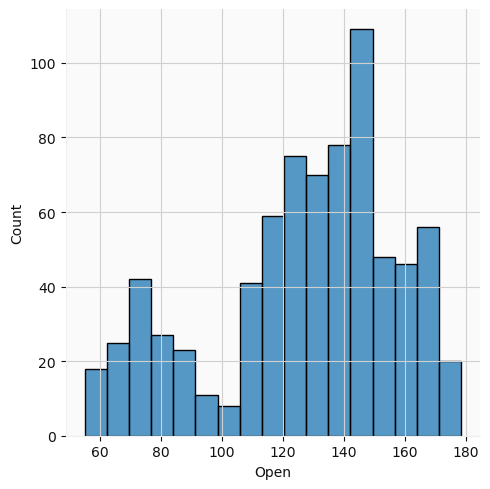

In [74]:
plt.figure(figsize=(14, 8))
sns.displot(data['Open'])
plt.show()

<Figure size 1400x800 with 0 Axes>

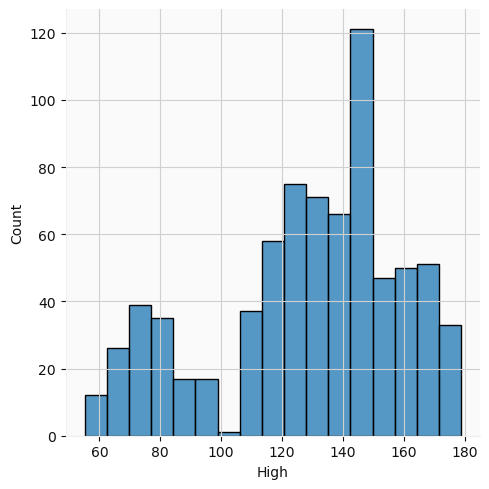

In [75]:
plt.figure(figsize=(14, 8))
sns.displot(data['High'])
plt.show()

<Figure size 1400x800 with 0 Axes>

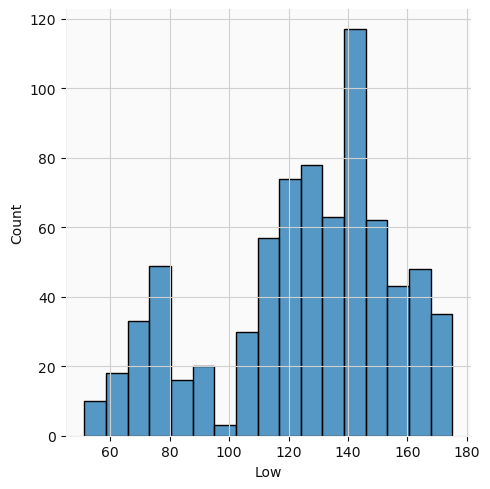

In [76]:
plt.figure(figsize=(14, 8))
sns.displot(data['Low'])
plt.show()

In [77]:
data.head()
type(data['Open'])

pandas.core.series.Series

In [78]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2020-01-02 to 2022-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   756 non-null    float64
 1   High    756 non-null    float64
 2   Low     756 non-null    float64
 3   Open    756 non-null    float64
 4   Volume  756 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.4 KB


In [79]:
data['Open'] = data['Open'].astype(float)   

/opt/anaconda3/lib/python3.13/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


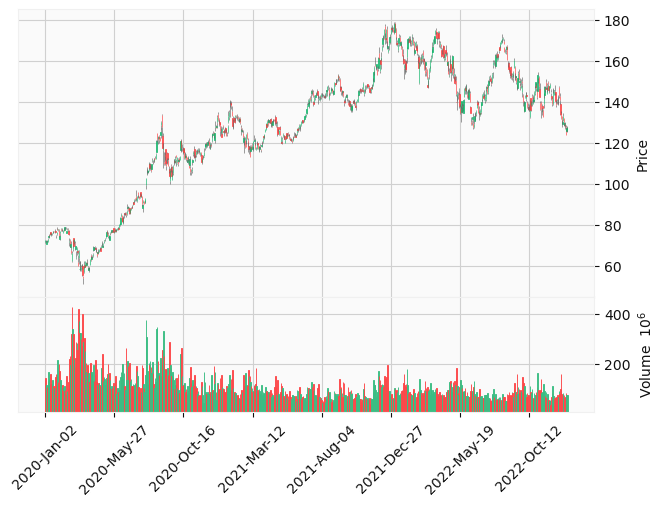

In [80]:
mpf.plot(
    data,
    type="candle",
    volume=True,
    style="yahoo"
)

Text(0.5, 1.0, 'Close Price with 20-Day Moving Average')

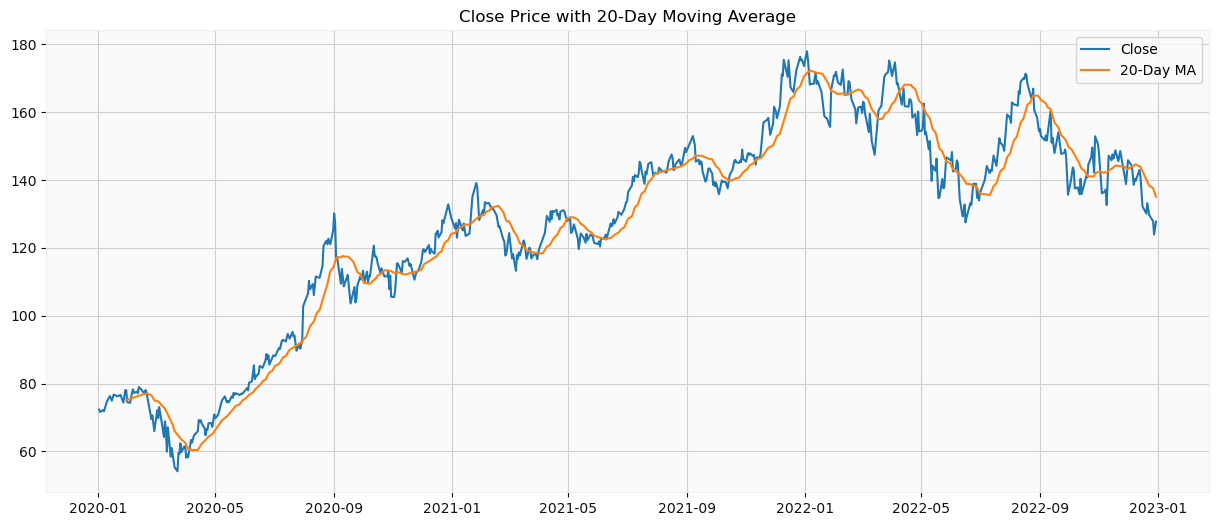

In [81]:
data["MA20"] = data["Close"].rolling(20).mean()

plt.figure(figsize=(15,6))

plt.plot(data.index, data["Close"], label="Close")
plt.plot(data.index, data["MA20"], label="20-Day MA")

plt.legend()
plt.title("Close Price with 20-Day Moving Average")

In [82]:
data['Close']

Date
2020-01-02     72.333885
2020-01-03     71.630646
2020-01-06     72.201416
2020-01-07     71.861839
2020-01-08     73.017822
                 ...    
2022-12-23    129.659424
2022-12-27    127.859924
2022-12-28    123.936523
2022-12-29    127.446938
2022-12-30    127.761604
Name: Close, Length: 756, dtype: float64

In [83]:
# finish visuals

## Feature Enginering

In [84]:
data.head(30)

Price,Close,High,Low,Open,Volume,MA20
Date,,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400,NaN
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000,NaN
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200,NaN
2020-01-09,74.568779,74.761442,73.742727,73.993187,170108400,NaN
2020-01-10,74.737358,75.300911,74.236431,74.802387,140644800,NaN
2020-01-13,76.334099,76.360594,74.934866,75.052878,121532000,NaN
2020-01-14,75.303322,76.480993,75.180503,76.271471,161954400,NaN


In [85]:
data["MA50_Close"] = data["Close"].rolling(50).mean()
data.head(60)

Price,Close,High,Low,Open,Volume,MA20,MA50_Close
Date,,,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400,NaN,NaN
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000,NaN,NaN
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200,NaN,NaN
2020-01-09,74.568779,74.761442,73.742727,73.993187,170108400,NaN,NaN
2020-01-10,74.737358,75.300911,74.236431,74.802387,140644800,NaN,NaN
2020-01-13,76.334099,76.360594,74.934866,75.052878,121532000,NaN,NaN
2020-01-14,75.303322,76.480993,75.180503,76.271471,161954400,NaN,NaN


In [86]:
data['Daily_Return'] = data['Close'].pct_change()
data.head(60)

Price,Close,High,Low,Open,Volume,MA20,MA50_Close,Daily_Return
Date,,,,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400,NaN,NaN,NaN
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,-0.009722
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,0.007968
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000,NaN,NaN,-0.004703
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200,NaN,NaN,0.016086
2020-01-09,74.568779,74.761442,73.742727,73.993187,170108400,NaN,NaN,0.021241
2020-01-10,74.737358,75.300911,74.236431,74.802387,140644800,NaN,NaN,0.002261
2020-01-13,76.334099,76.360594,74.934866,75.052878,121532000,NaN,NaN,0.021365
2020-01-14,75.303322,76.480993,75.180503,76.271471,161954400,NaN,NaN,-0.013503


## Calendar Features

In [87]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,MA50_Close,Daily_Return
Date,,,,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400,NaN,NaN,NaN
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,-0.009722
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,0.007968
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000,NaN,NaN,-0.004703
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200,NaN,NaN,0.016086


In [88]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2020-01-02 to 2022-12-30
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         756 non-null    float64
 1   High          756 non-null    float64
 2   Low           756 non-null    float64
 3   Open          756 non-null    float64
 4   Volume        756 non-null    int64  
 5   MA20          737 non-null    float64
 6   MA50_Close    707 non-null    float64
 7   Daily_Return  755 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 53.2 KB


In [89]:
data.index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2022-12-16', '2022-12-19', '2022-12-20', '2022-12-21',
               '2022-12-22', '2022-12-23', '2022-12-27', '2022-12-28',
               '2022-12-29', '2022-12-30'],
              dtype='datetime64[ns]', name='Date', length=756, freq=None)

In [90]:
data["Day"] = data.index.day

In [91]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,MA50_Close,Daily_Return,Day
Date,,,,,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400,NaN,NaN,NaN,2
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,-0.009722,3
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,0.007968,6
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000,NaN,NaN,-0.004703,7
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200,NaN,NaN,0.016086,8


In [92]:
data["Weekday"] = data.index.weekday

In [93]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,MA50_Close,Daily_Return,Day,Weekday
Date,,,,,,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400,NaN,NaN,NaN,2,3
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,-0.009722,3,4
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,0.007968,6,0
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000,NaN,NaN,-0.004703,7,1
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200,NaN,NaN,0.016086,8,2


In [94]:
data["Month"]= data.index.month

In [95]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,MA50_Close,Daily_Return,Day,Weekday,Month
Date,,,,,,,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400,NaN,NaN,NaN,2,3,1
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,-0.009722,3,4,1
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,0.007968,6,0,1
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000,NaN,NaN,-0.004703,7,1,1
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200,NaN,NaN,0.016086,8,2,1


In [96]:
data["Year"] = data.index.year

In [97]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,MA50_Close,Daily_Return,Day,Weekday,Month,Year
Date,,,,,,,,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400,NaN,NaN,NaN,2,3,1,2020
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,-0.009722,3,4,1,2020
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,0.007968,6,0,1,2020
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000,NaN,NaN,-0.004703,7,1,1,2020
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200,NaN,NaN,0.016086,8,2,1,2020


In [98]:
# mean imputation
data['MA20']= data['MA20'].fillna(data['MA20'].mean())
data['MA50_Close']= data['MA50_Close'].fillna(data['MA50_Close'].mean())
data['Daily_Return']= data['Daily_Return'].fillna(data['Daily_Return'].mean())

In [99]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,MA50_Close,Daily_Return,Day,Weekday,Month,Year
Date,,,,,,,,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400,127.756422,128.563919,0.001024,2,3,1,2020
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,127.756422,128.563919,-0.009722,3,4,1,2020
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,127.756422,128.563919,0.007968,6,0,1,2020
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000,127.756422,128.563919,-0.004703,7,1,1,2020
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200,127.756422,128.563919,0.016086,8,2,1,2020


## Feature Selection

In [100]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'MA20', 'MA50_Close',
       'Daily_Return', 'Day', 'Weekday', 'Month', 'Year'],
      dtype='object', name='Price')

In [101]:
x = data.drop(columns = ['Close'], axis = 1)


In [102]:
y = data['Close']

## Time-Series (Train, Test, Split)

In [103]:
# Normal dataset
from sklearn.model_selection import train_test_split

In [104]:
train_size = int(len(x)*0.7)
val_size = int(len(x)*0.3)

In [105]:
x_train = x.iloc[:train_size]
y_train = y.iloc[:train_size]

In [106]:
train_size

529

In [107]:
x_test = x.iloc[train_size:]
y_test = y.iloc[train_size:]


In [108]:
print(f"x_train = {x_train.shape}")
print(f"y_train = {y_train.shape}")

x_train = (529, 11)
y_train = (529,)


In [109]:
print(f"x_test = {x_test.shape}")
print(f"y_test = {y_test.shape}")

x_test = (227, 11)
y_test = (227,)


## Model Training 

In [110]:
from sklearn.linear_model import LinearRegression

In [111]:
model = LinearRegression()

In [112]:
x.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2020-01-02 to 2022-12-30
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   High          756 non-null    float64
 1   Low           756 non-null    float64
 2   Open          756 non-null    float64
 3   Volume        756 non-null    int64  
 4   MA20          756 non-null    float64
 5   MA50_Close    756 non-null    float64
 6   Daily_Return  756 non-null    float64
 7   Day           756 non-null    int32  
 8   Weekday       756 non-null    int32  
 9   Month         756 non-null    int32  
 10  Year          756 non-null    int32  
dtypes: float64(6), int32(4), int64(1)
memory usage: 59.1 KB


In [113]:
x.isna().sum()

Price
High            0
Low             0
Open            0
Volume          0
MA20            0
MA50_Close      0
Daily_Return    0
Day             0
Weekday         0
Month           0
Year            0
dtype: int64

In [114]:
model.fit(x_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [115]:
predictions = model.predict(x_test)

In [116]:
predictions

array([168.51284826, 170.7504477 , 172.03275449, 169.06417035,
       166.10736574, 164.72120548, 168.76452482, 168.03319494,
       165.84144758, 164.33113109, 160.47335413, 158.49075581,
       156.76230664, 159.89189962, 160.73459705, 160.58462403,
       162.656541  , 163.39035889, 159.79238509, 157.9189386 ,
       156.22161311, 159.13767624, 153.75809914, 152.65918756,
       148.51869467, 151.50401023, 155.12875367, 156.48067618,
       159.92383325, 161.78026881, 164.83896174, 167.54333893,
       169.54974712, 170.41052807, 170.78236723, 174.55895279,
       173.97832196, 171.52422679, 169.52275225, 173.95636087,
       171.8285546 , 167.62256237, 168.21878862, 166.19415256,
       162.69759383, 165.12731872, 166.38724762, 163.49158162,
       161.92778744, 163.14768535, 163.6101807 , 165.27795165,
       160.38861016, 157.75083596, 154.72005811, 154.93715062,
       160.54723631, 157.91583157, 152.50808923, 155.78265423,
       161.95099377, 154.10217047, 154.42263716, 149.54

In [119]:
data_pred = pd.DataFrame(y_test)
data_pred['Predictions Value'] = predictions
#data_pred['Actual Value'] = y_test


In [120]:
data_pred

,Close,Predictions Value
Date,,
2022-02-07,168.035019,168.512848
2022-02-08,171.138062,170.750448
2022-02-09,172.557434,172.032754
2022-02-10,168.485260,169.064170
2022-02-11,165.078781,166.107366
...,...,...
2022-12-23,129.659424,129.268460
2022-12-27,127.859924,127.564805
2022-12-28,123.936523,125.799297


## Model Evaluation

In [121]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error

In [122]:
#Calculate mse
mse = mean_squared_error(y_test, predictions)

In [123]:
print(f"MSE:{mse:.4f}")

MSE:0.9219


In [124]:
rmse = root_mean_squared_error(y_test, predictions)
print(f"RMSE:{rmse:.4f}")

RMSE:0.9602
